In [1]:
# These are the modules we will use for loading the data and fitting.
from dysh.spectra import Spectrum
from specutils.fitting import fit_lines
from astropy.modeling import models
from astropy import units as u
from dysh.log import init_logging

# These modules are used for file I/O
from dysh.util.files import dysh_data
from pathlib import Path

In [2]:
init_logging(2)

# also create a local "output" directory where temporary notebook files can be stored.
output_dir = Path.cwd() / "output"
output_dir.mkdir(exist_ok=True)

In [3]:
filename = dysh_data(example="nod-W/outputs/M82_ifnum_3_polavg.fits")

16:02:28.597 I url: http://www.gb.nrao.edu/dysh//example_data/nod-W/outputs/M82_ifnum_3_polavg.fits


Odd-1, did not find /bigdisk/data/gbt/dysh_data/example_data/nod-W/outputs/M82_ifnum_3_polavg.fits
M82_ifnum_3_polavg.fits already downloaded


In [4]:
spec = Spectrum.read(filename, format="fits")

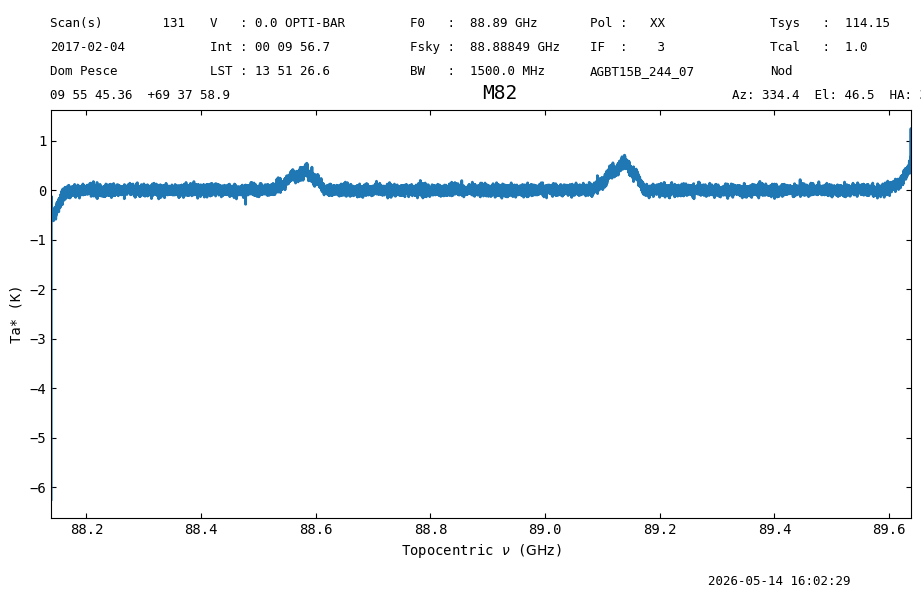

In [5]:
sp_plt = spec.plot(xaxis_unit="GHz")

In [6]:
spec = spec[88.2*u.GHz:89.5*u.GHz]

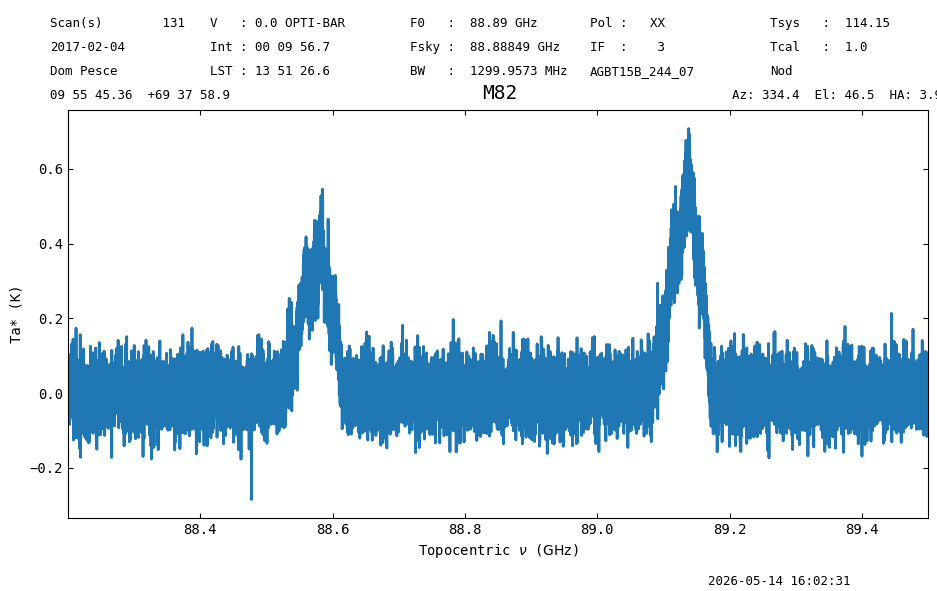

In [7]:
spec_plt = spec.plot(xaxis_unit="GHz")

In [8]:
g_init = models.Gaussian1D(amplitude=0.5*u.K, mean=88.55*u.GHz, stddev=0.1*u.GHz)
g_fit = fit_lines(spec, g_init)
y_fit = g_fit(spec.spectral_axis)

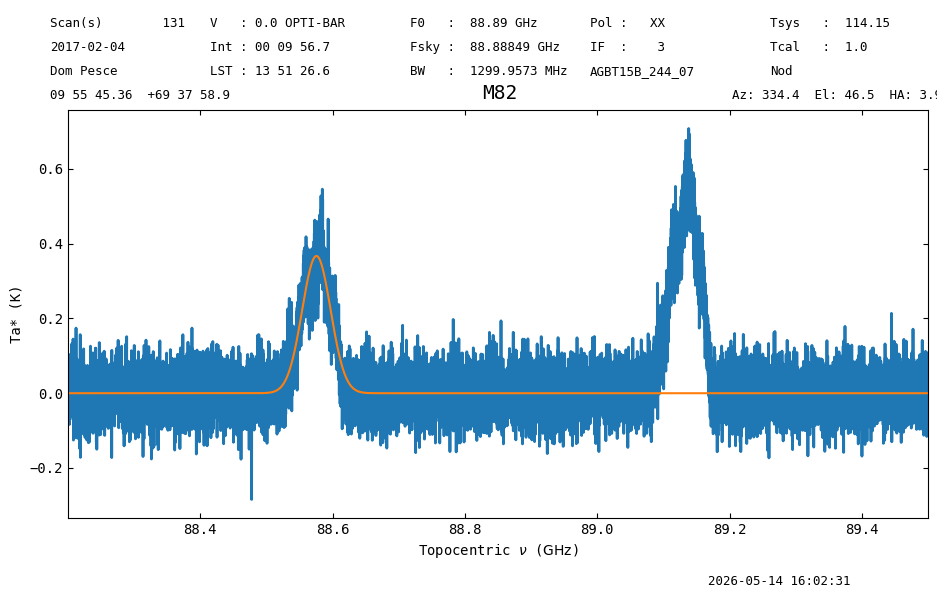

In [9]:
spec_plt.axis.plot(spec.spectral_axis.to("GHz"), y_fit, gid="1gauss")
spec_plt.figure # This will show the figure here.

In [10]:
g_fit.amplitude

Parameter('amplitude', value=0.3670704696308813, unit=K)

In [11]:
g_fit.amplitude.std

np.float64(0.006236258674343532)

In [12]:
g_init2 = models.Gaussian1D(amplitude=0.6*u.K, mean=89.15*u.GHz, stddev=0.1*u.GHz)
g_fit = fit_lines(spec, g_init + g_init2)
y_fit = g_fit(spec.spectral_axis)

In [13]:
spec_plt.clear_lines("1gauss")

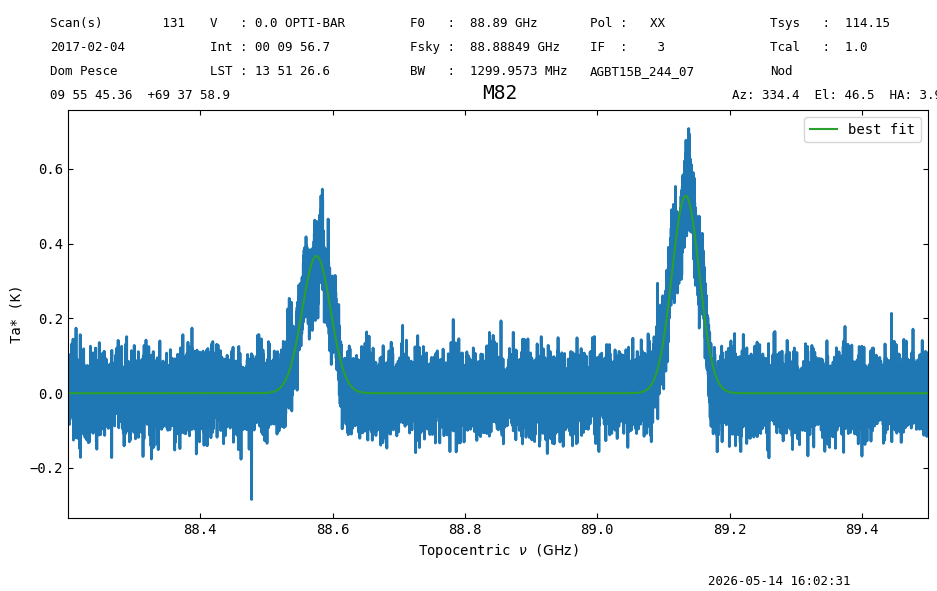

In [14]:
spec_plt.axis.plot(spec.spectral_axis.to("GHz"), y_fit, label="best fit")
spec_plt.axis.legend()
spec_plt.figure
spec_plt.show()

In [15]:
g_fit.amplitude_0

Parameter('amplitude', value=0.3670705202212676, unit=K)

In [16]:
g_fit.amplitude_1

Parameter('amplitude', value=0.5281505181498451, unit=K)

In [17]:
spec.check_stats(0.11606252 * u.K)

16:02:32.951 I Note: found 27 NaN (masked) values


16:02:32.952 I rms is OK 
